# Special Extra!!

Getting the best models on the planet to generate an SVG

Inspired by the legendary Simon Willison's Pelican riding a bike test

Key point: this is a very different task to image generation! The model needs to describe the image with lines and shapes.

### This uses OpenRouter.ai so that we easily access the latest models

In [1]:
from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os
load_dotenv(override=True)

True

In [15]:
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

if OPENROUTER_API_KEY and OPENROUTER_API_KEY.startswith("sk-or-"):
    print("OPENROUTER_API_KEY looks good so far")
else:
    print("OPENROUTER_API_KEY doesn't seem right")

OPENROUTER_API_KEY looks good so far


In [16]:
openrouter = OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

In [17]:
challenge = "A Peacock riding an airlpane"
prompt = f"Generate an SVG of {challenge}. Respond with the SVG only, no code blocks."
messages = [{"role": "user", "content": prompt}]

In [18]:
def artist(model, effort=None):
    try:
        start = datetime.now()
        response = openrouter.chat.completions.create(model=model, messages=messages, reasoning_effort=effort)
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end - start).total_seconds()
        heading = f"### {model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"
    except Exception as e:
        print(f"Model {model} failed: {e}")
        heading = f"### {model}\n**Error:** {e}\n\n"
        return heading, None
    return heading, result

In [23]:
from openai import AsyncOpenAI
import asyncio

async_openrouter = AsyncOpenAI(
    base_url=OPENROUTER_BASE_URL,
    api_key=OPENROUTER_API_KEY,
)

async def async_artist(model, effort=None):
    try:
        start = datetime.now()
        kwargs = {"model": model, "messages": messages}
        if effort is not None:
            kwargs["reasoning_effort"] = effort

        response = await async_openrouter.chat.completions.create(**kwargs)
        result = response.choices[0].message.content
        elapsed = (datetime.now() - start).total_seconds()
        heading = f"### {model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"
        return heading, result
    except Exception as e:
        return f"### {model}\n**Error:** {e}\n\n", None

models = [
    "nvidia/nemotron-3-ultra-550b-a55b:free",
    "poolside/laguna-s-2.1:free",
    "inclusionai/ling-3.0-flash-fin:free",
    "deepseek/deepseek-v4-flash-0731:free",
]

results = await asyncio.gather(*(async_artist(model) for model in models))

### nvidia/nemotron-3-ultra-550b-a55b:free
**Time:** 5 min 31 s



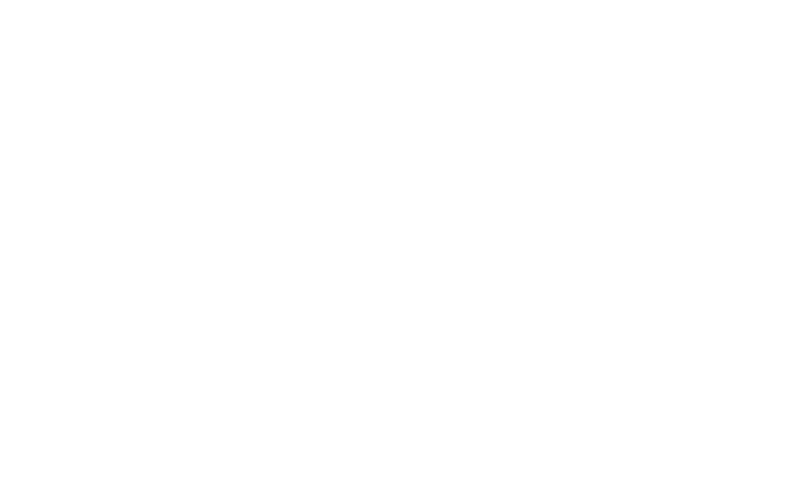

### poolside/laguna-s-2.1:free
**Time:** 0 min 23 s



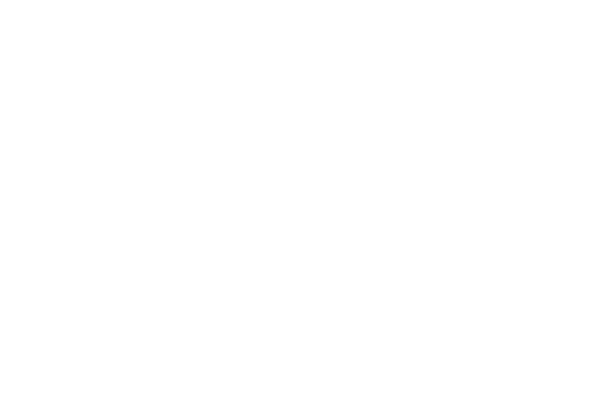

### inclusionai/ling-3.0-flash-fin:free
**Time:** 0 min 12 s



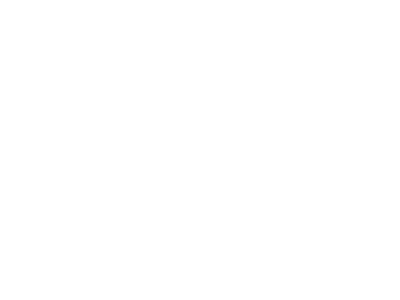

### deepseek/deepseek-v4-flash-0731:free
**Time:** 10 min 37 s



Error displaying result: not well-formed (invalid token): line 1, column 1


In [25]:
for result in results:
    try:
        display(Markdown(result[0]))
        reveal(result[1])
        time.sleep(12)
    except Exception as e:
        print(f"Error displaying result: {e}")

## In Week 4 we will have more scientific ways to compare models..

but this was quite fun.

In [29]:
openrouter.chat.completions.create(
    model="deepseek/deepseek-v4-flash-0731:free",
    messages=[{"role": "user", "content": prompt}]
).choices[0].message.content

'I’ll create a playful SVG illustration of a peacock riding an airplane, set against a bright sky with clouds.\n\n<svg width="800" height="600" viewBox="0 0 800 600" xmlns="http://www.w3.org/2000/svg">\n    <defs>\n        <linearGradient id="skyGrad" x1="0%" y1="0%" x2="0%" y2="100%">\n            <stop offset="0%" stop-color="#4CC9F0" />\n            <stop offset="100%" stop-color="#90E0EF" />\n        </linearGradient>\n\n        <linearGradient id="featherGrad" x1="0%" y1="0%" x2="100%" y2="0%">\n            <stop offset="0%" stop-color="#2A9D8F" />\n            <stop offset="100%" stop-color="#1D3557" />\n        </linearGradient>\n\n        <filter id="shadow" x="-20%" y="-20%" width="140%" height="140%">\n            <feDropShadow dx="0" dy="10" stdDeviation="8" flood-color="#000" flood-opacity="0.25" />\n        </filter>\n\n        <!-- Background feather (darker, longer) -->\n        <g id="feather">\n            <line x1="0" y1="0" x2="-175" y2="0" stroke="#E9C46A" stroke-wi